In [2]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d

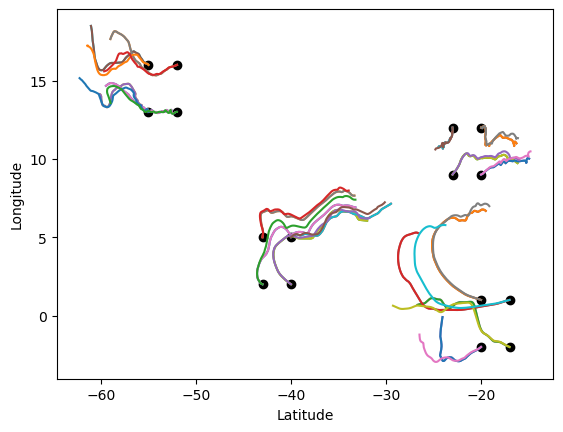

In [3]:
#Opening simulation data files
DS = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z0.zarr")
DS1 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z1.zarr")
DS2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z2.zarr")
DSJ = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z0_J.zarr")
DSB = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z0_Bonner.zarr")
DSOS = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z0_oldstokeskernelagain.zarr")
DSRS = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z0_directstokes.zarr")
DSDIS = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Simulations_part1/SIM_July_z0_depth_integrated_stokes.zarr")

plt.plot(DS.lon.T, DS.lat.T, "-")
plt.plot(DSOS.lon.T, DSOS.lat.T, "-")
plt.plot(DSRS.lon.T, DSRS.lat.T, "-")
plt.scatter(DS.lon.T[0], DS.lat.T[0], color='black')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

In [5]:
#Starttime definition
starttimejuly = datetime(2024,7,1)

#Definition of time array in hours and days
time_in_hours = ((DS['time']-DS['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DS['time'] - DS['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

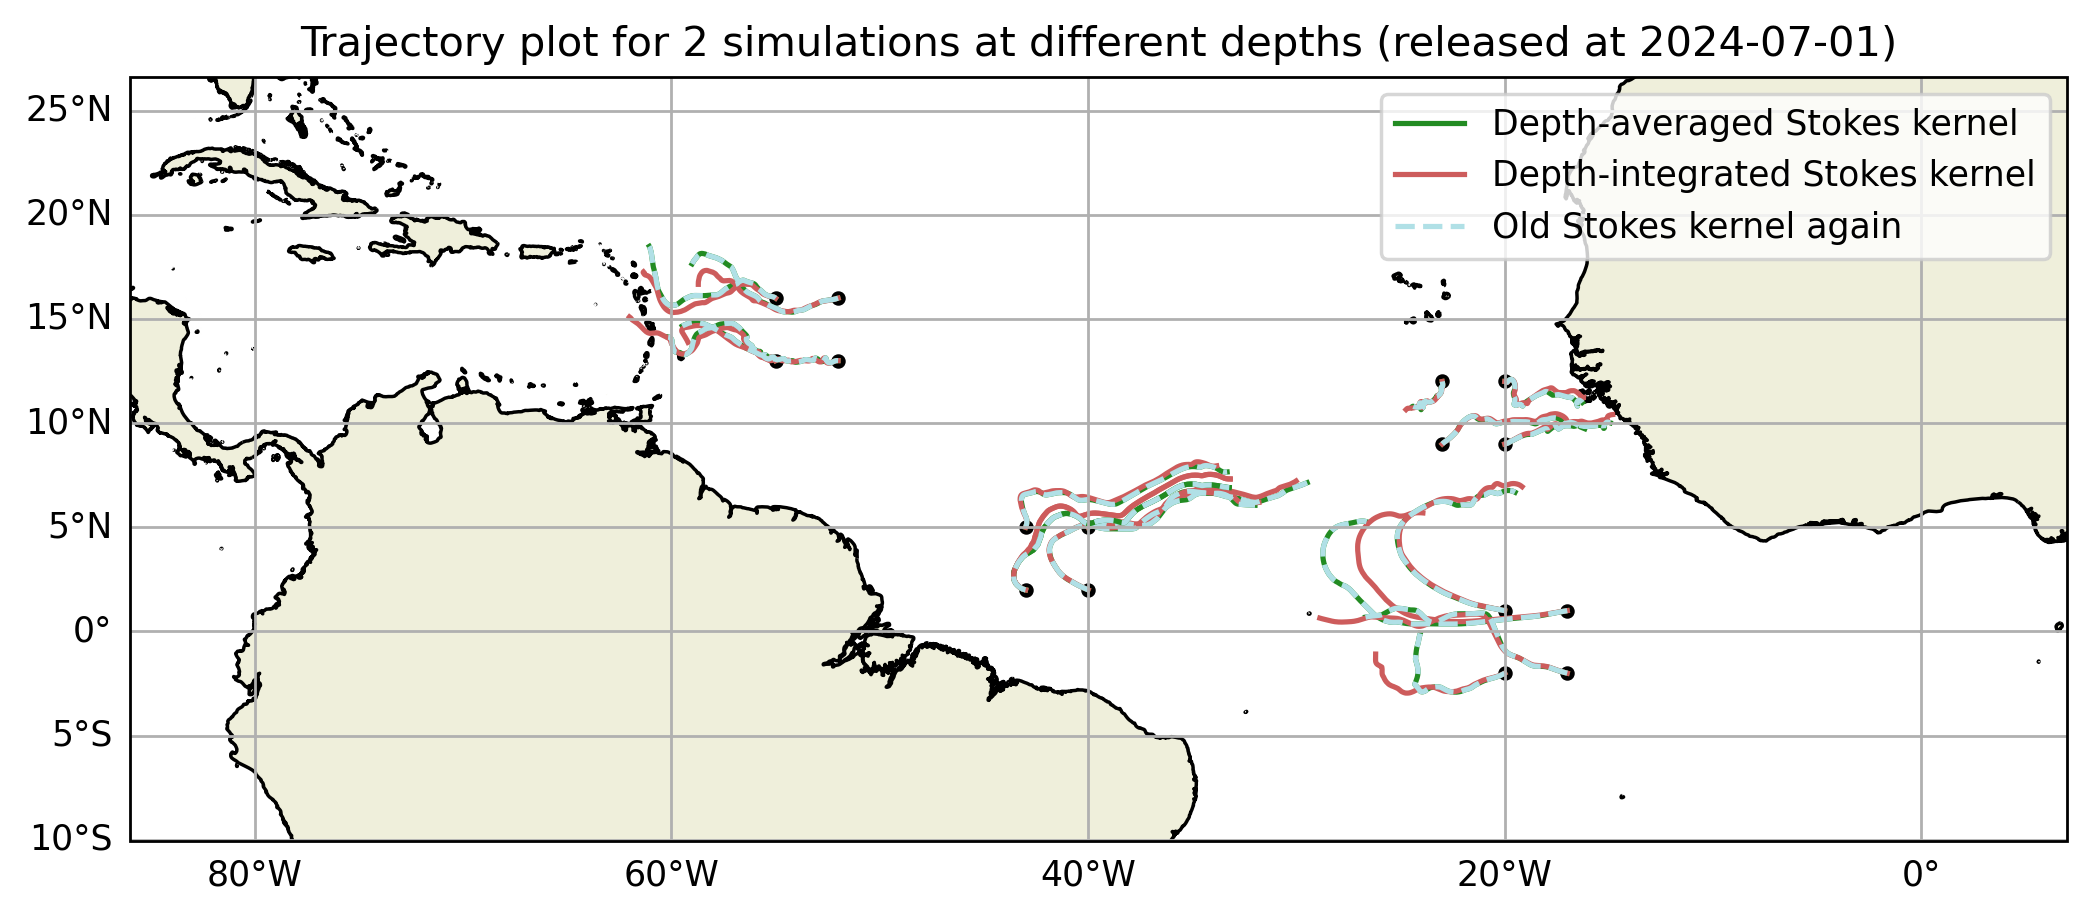

In [ ]:
#Figure to plot trajectories
fig2 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
#Startlocations scatterplot
pplot = ax.scatter(DS.lon[:,0], DS.lat[:,0], s = 10 ,color='black') #Transposing lon and lat arrays!
#Trajectoryplot
tplot = ax.plot(DS.lon.T, DS.lat.T, "-", color = 'forestgreen') #Transposing lon and lat arrays!
t4plot = ax.plot(DSDIS.lon.T, DSDIS.lat.T, "-" , color = 'indianred') #Transposing lon and lat arrays!
t3plot = ax.plot(DSOS.lon.T, DSOS.lat.T, "--" , color = 'powderblue') #Transposing lon and lat arrays!
t = ax.plot(DS.lon[0,:].T, DS.lat[0,:].T, "-", color = 'forestgreen' , label = 'Depth-averaged Stokes kernel') #Transposing lon and lat arrays!
t2 = ax.plot(DSDIS.lon[0,:].T, DSDIS.lat[0,:].T, "-", color = 'indianred', label = 'Depth-integrated Stokes kernel')
t3 = ax.plot(DSOS.lon[0,:].T, DSOS.lat[0,:].T, "--", color = 'powderblue', label = 'Old Stokes kernel again')
#t4plot = ax.plot(DSJ.lon.T, DSJ.lat.T, "-") #Transposing lon and lat arrays!
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Trajectory plot for 2 simulations at different depths (released at {starttimejuly.date()})')
ax.legend()
ax.set_extent([-86,7,-7,19])
plt.show()

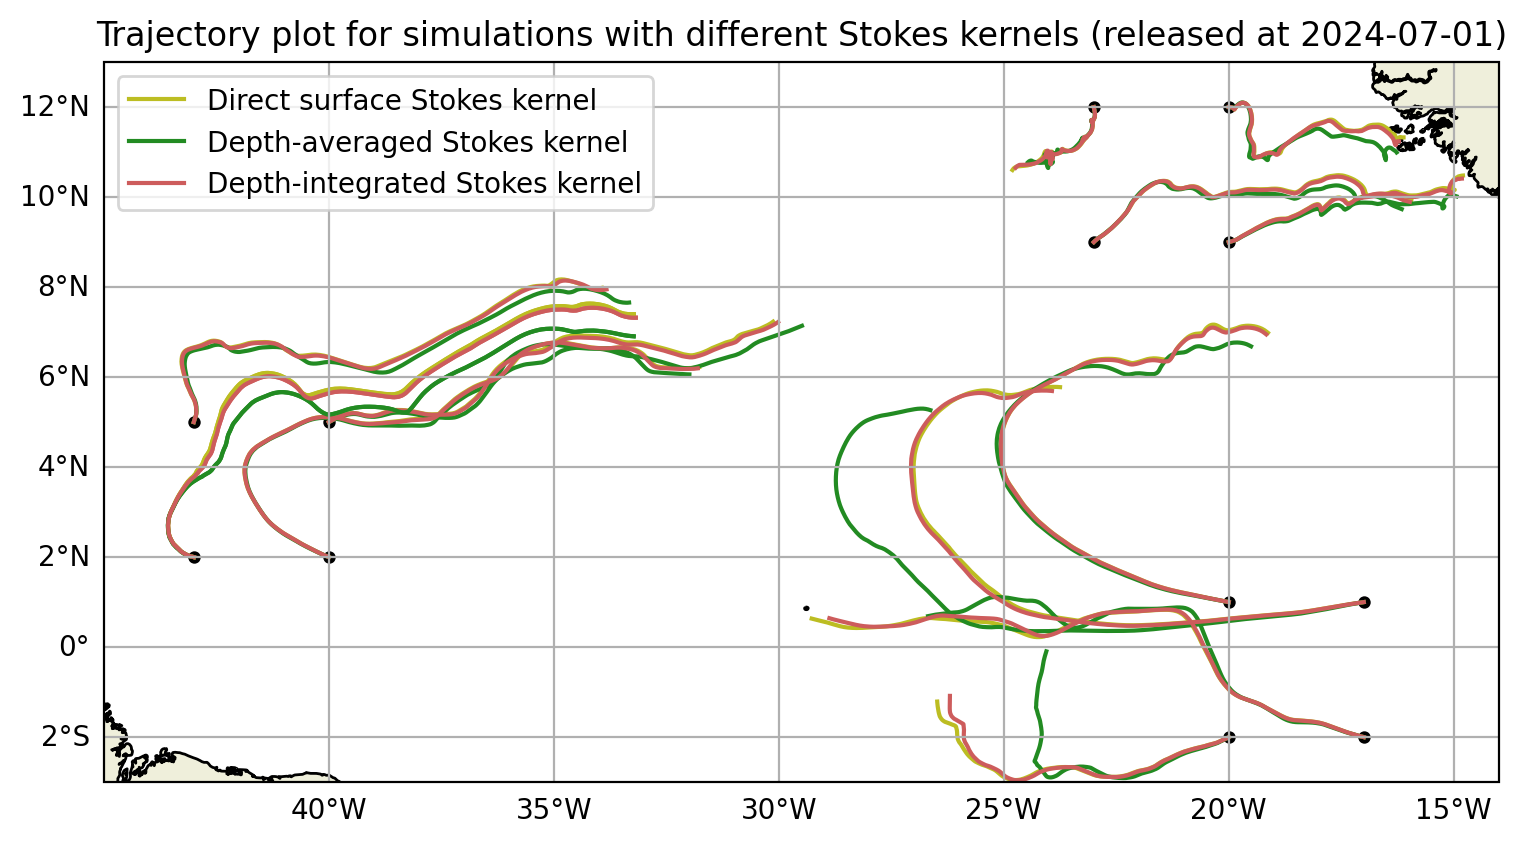

In [7]:
#Figure to plot trajectories zoomed-in
fig2 = plt.figure(figsize = (9,6), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())

#Starting locations scatterplot
pplot = ax.scatter(DS.lon[:,0], DS.lat[:,0], s = 12 ,color='black') #

#Trajectories #Transposing lon and lat arrays!
trplot =    ax.plot(DSRS.lon.T, DSRS.lat.T, "-", color = 'tab:olive') 
tplot =     ax.plot(DS.lon.T, DS.lat.T, "-", color = 'forestgreen') 
tdiplot =   ax.plot(DSDIS.lon.T, DSDIS.lat.T, "-" , color = 'indianred') 
tr =        ax.plot(DSRS.lon[0,:].T, DSRS.lat[0,:].T, "-", color = 'tab:olive', label = 'Direct surface Stokes kernel')
t =         ax.plot(DS.lon[0,:].T, DS.lat[0,:].T, "-", color = 'forestgreen' , label = 'Depth-averaged Stokes kernel') 
tdi =       ax.plot(DSDIS.lon[0,:].T, DSDIS.lat[0,:].T, "-", color = 'indianred', label = 'Depth-integrated Stokes kernel')

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Trajectory plot for simulations with different Stokes kernels (released at {starttimejuly.date()})')
ax.legend(loc = 'upper left')
ax.set_extent([-45,-14,-3,13])
plt.show()

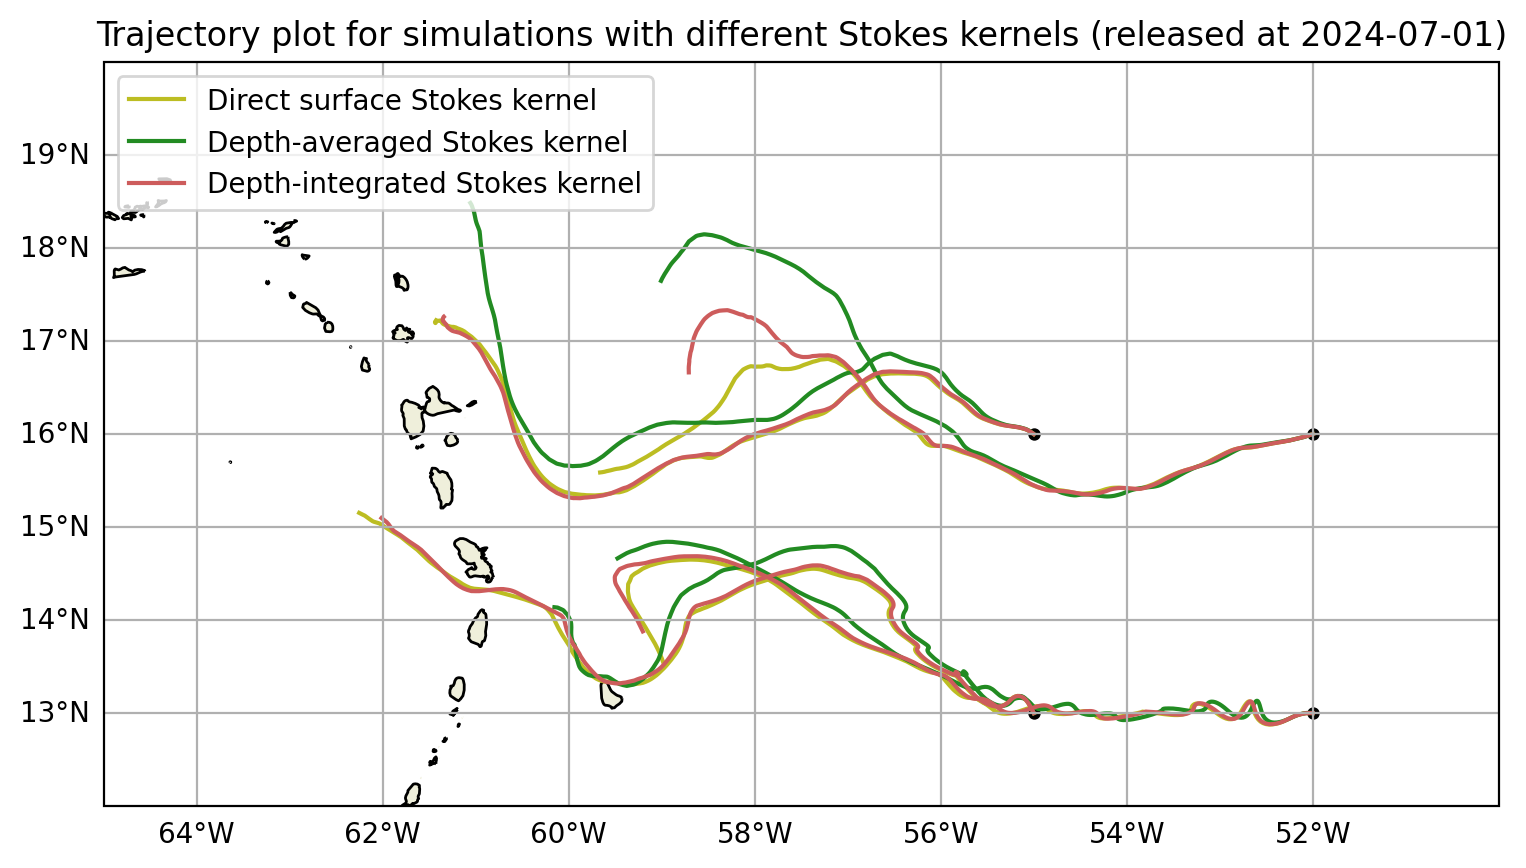

In [37]:
#Figure to plot trajectories zoomed-in
fig2 = plt.figure(figsize = (9,5), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())

#Starting locations scatterplot
pplot = ax.scatter(DS.lon[:,0], DS.lat[:,0], s = 12 ,color='black') #

#Trajectories #Transposing lon and lat arrays!
trplot =    ax.plot(DSRS.lon.T, DSRS.lat.T, "-", color = 'tab:olive') 
tplot =     ax.plot(DS.lon.T, DS.lat.T, "-", color = 'forestgreen') 
tdiplot =   ax.plot(DSDIS.lon.T, DSDIS.lat.T, "-" , color = 'indianred') 
tr =        ax.plot(DSRS.lon[0,:].T, DSRS.lat[0,:].T, "-", color = 'tab:olive', label = 'Direct surface Stokes kernel')
t =         ax.plot(DS.lon[0,:].T, DS.lat[0,:].T, "-", color = 'forestgreen' , label = 'Depth-averaged Stokes kernel') 
tdi =       ax.plot(DSDIS.lon[0,:].T, DSDIS.lat[0,:].T, "-", color = 'indianred', label = 'Depth-integrated Stokes kernel')

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Trajectory plot for simulations with different Stokes kernels (released at {starttimejuly.date()})')
ax.legend(loc = 'upper left')
ax.set_extent([-65,-50, 12,20])
plt.show()

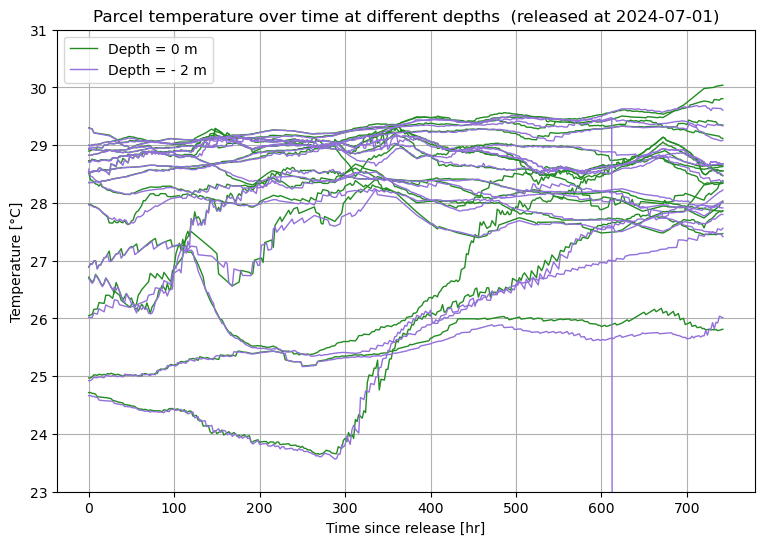

In [32]:
figtemp = plt.figure(figsize = (9,6), dpi=100)
plt.plot(time_in_hours.transpose(), DS.temperature.transpose(), c = 'forestgreen' , linewidth = 1)
plt.plot(time_in_hours[0,:].transpose(), DS.temperature[0,:].transpose(), c = 'forestgreen', label = 'Depth = 0 m', linewidth = 1 )
plt.plot(time_in_hours.transpose(), DS2.temperature.transpose() , c = 'mediumpurple', linewidth = 1)
plt.plot(time_in_hours[0,:].transpose(), DS2.temperature[0,:].transpose(), c = 'mediumpurple', label = 'Depth = - 2 m', linewidth = 1 )
plt.title(f'Parcel temperature over time at different depths  (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Temperature [°C]')
plt.ylim(23,31)
plt.legend(loc='upper left')
plt.grid()
plt.show()

In [15]:
DS['z']

print((DS['z'].values[0,0]))
print((DS1['z'].values[0,0]))
print((DS2['z'].values[0,0]))

0.0
1.0
2.0


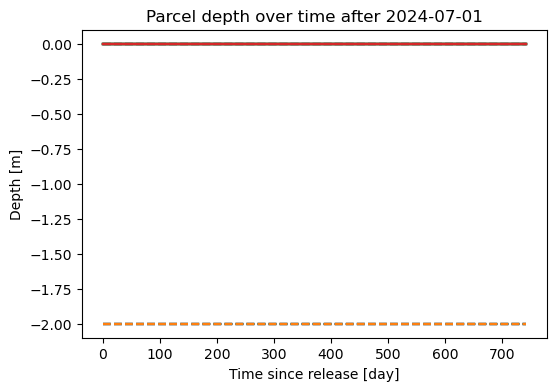

In [15]:
figz = plt.figure(figsize = (6,4))
plt.plot(time_in_hours.transpose(), -DS.z.transpose() )
plt.plot(time_in_hours.transpose(), -DS2.z.transpose() , "--")
plt.plot(time_in_hours.transpose(), -DSRS.z.transpose() , "--")
plt.plot(time_in_hours.transpose(), -DSOS.z.transpose() , "-")
plt.title(f'Parcel depth over time after {starttimejuly.date()}')
plt.xlabel('Time since release [day]')
plt.ylabel('Depth [m]')
plt.show()

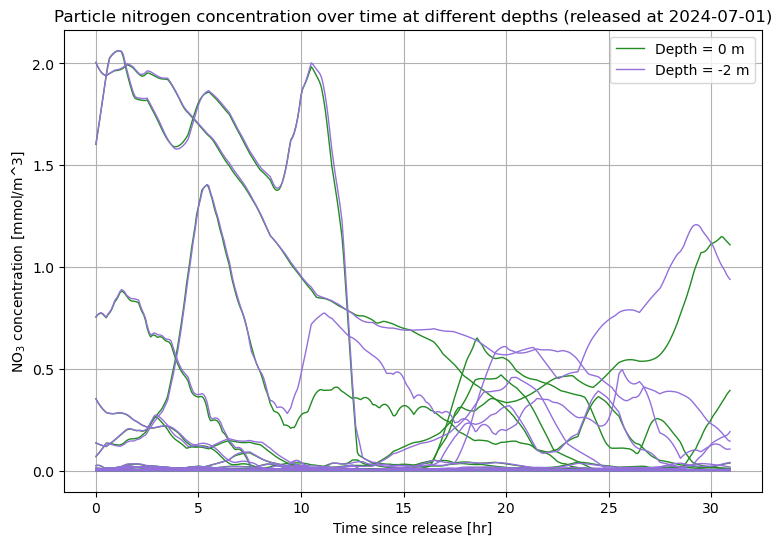

In [12]:
figN = plt.figure(figsize = (9,6), dpi=100)
plt.plot(time_in_days[0,:].transpose()  , DS.nitrogen[0,:].transpose() , linewidth = 1 , color = 'forestgreen', label = 'Depth = 0 m')
plt.plot(time_in_days.transpose()  , DS.nitrogen.transpose() , linewidth = 1 , color = 'forestgreen')
plt.plot(time_in_days[0,:].transpose()  , DS2.nitrogen[0,:].transpose() , linewidth = 1 , color = 'mediumpurple', label = 'Depth = -2 m')
plt.plot(time_in_days.transpose()  , DS2.nitrogen.transpose() , linewidth = 1 , color = 'mediumpurple')
plt.title(f'Particle nitrogen concentration over time at different depths (released at {starttimejuly.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel(f'NO$_3$ concentration [mmol/m^3]')
#plt.ylim(-0.005,0.05)
plt.legend()
plt.grid()
plt.show()

In [ ]:
import calculate_distance as cd
x0 = DSOS["lon"][:,:].values
y0 = DSOS["lat"][:,:].values

x2 = DSDIS["lon"][:,:].values
y2 = DSDIS["lat"][:,:].values

distance = np.cumsum( np.sqrt(np.square(np.diff(x0)) + np.square(np.diff(y0))), axis=1)  # d = (dx^2 + dy^2)^(1/2)

dist_km_tot = cd.cumulative_distance_01(DSRS)
dist_km_tot_NS = cd.cumulative_distance_01(DSDIS)

print(np.shape(x0), np.shape(x2), np.shape(distance), np.shape(dist_km_tot))

(16, 400) (16, 400) (16, 400) (16, 399) (16, 400)


In [17]:
#Calculating cumulative distance in kilometers between trajectories of two simulations
dist_km_ref_av_stokes = cd.cumulative_distance_01(DSRS - DSOS)
dist_km_ref_di_stokes = cd.cumulative_distance_01(DSRS - DSDIS)

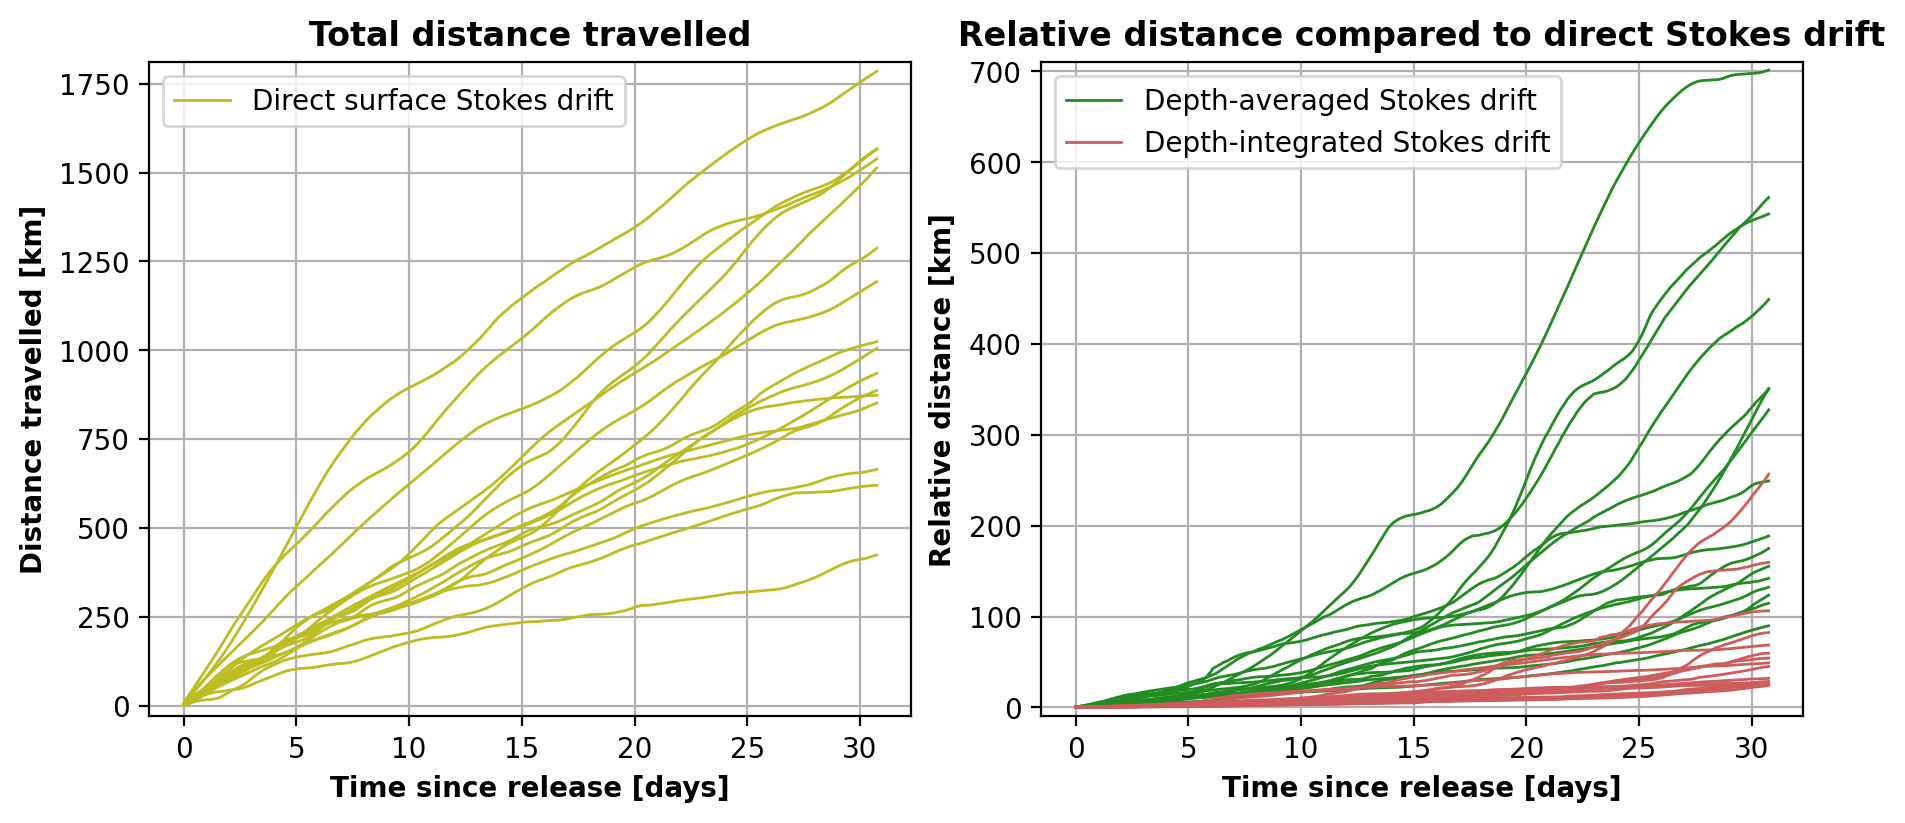

In [38]:
#Plotting distance against time that the parcels travelled
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True, dpi = 200)
#fig.suptitle('Relative distance compared to direct surface Stokes drift', weight='bold')

ax1.set_title('Total distance travelled', weight = 'bold')
ax1.set_ylabel("Distance travelled [km]", weight = 'bold')
ax1.set_xlabel("Time since release [days]", weight="bold")
d_plot = ax1.plot(time_in_days[:1,:-30].transpose(), dist_km_tot[:1,:-30].transpose(), linewidth = 1,  color = 'tab:olive', label = 'Direct surface Stokes drift')
d_plot = ax1.plot(time_in_days[1:,:-30].transpose(), dist_km_tot[1:,:-30].transpose(), linewidth = 1, color = 'tab:olive')
ax1.grid()
ax1.legend()
ax1.set_ylim(-30,1810)

ax2.set_title('Relative distance compared to direct Stokes drift', weight = 'bold')
ax2.set_ylabel("Relative distance [km]", weight = 'bold')
ax2.set_xlabel("Time since release [days]", weight="bold")
d_plot_t = ax2.plot(time_in_days[:1,:-30].transpose(), dist_km_ref_av_stokes[:1,:-30].transpose(), linewidth = 1, color='forestgreen', label = 'Depth-averaged Stokes drift')
d_plot_t = ax2.plot(time_in_days[1:,:-30].transpose(), dist_km_ref_av_stokes[1:,:-30].transpose(), linewidth = 1, color='forestgreen')
d_plot_t = ax2.plot(time_in_days[:1,:-30].transpose(), dist_km_ref_di_stokes[:1,:-30].transpose(), linewidth = 1, color='indianred', label = 'Depth-integrated Stokes drift')
d_plot_t = ax2.plot(time_in_days[1:,:-30].transpose(), dist_km_ref_di_stokes[1:,:-30].transpose(), linewidth = 1, color='indianred')
ax2.set_ylim(-10,710)
ax2.legend()
ax2.grid()
plt.show()

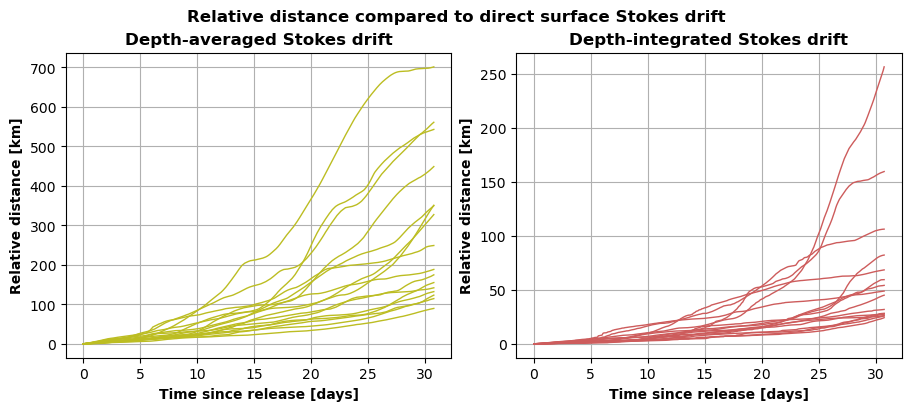

In [27]:
#Plotting distance against time that the parcels travelled
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
fig.suptitle('Relative distance compared to direct surface Stokes drift', weight='bold')

ax1.set_ylabel("Relative distance [km]", weight = 'bold')
ax1.set_xlabel("Time since release [days]", weight="bold")
d_plot = ax1.plot(time_in_days[:1,:-30].transpose(), dist_km_ref_av_stokes[:1,:-30].transpose(), linewidth = 1,  color = 'tab:olive', label = 'Distance travelled')
d_plot = ax1.plot(time_in_days[1:,:-30].transpose(), dist_km_ref_av_stokes[1:,:-30].transpose(), linewidth = 1, color = 'tab:olive')
ax1.set_title('Depth-averaged Stokes drift', weight = 'bold')
ax1.grid()

ax2.set_ylabel("Relative distance [km]", weight = 'bold')
ax2.set_xlabel("Time since release [days]", weight="bold")
d_plot_t = ax2.plot(time_in_days[:1,:-30].transpose(), dist_km_ref_di_stokes[:1,:-30].transpose(), linewidth = 1, color='indianred', label = 'Difference')
d_plot_t = ax2.plot(time_in_days[1:,:-30].transpose(), dist_km_ref_di_stokes[1:,:-30].transpose(), linewidth = 1, color='indianred')
#ax2.set_ylim(-10,710)
ax2.set_title('Depth-integrated Stokes drift', weight = 'bold')
ax2.grid()
plt.show()

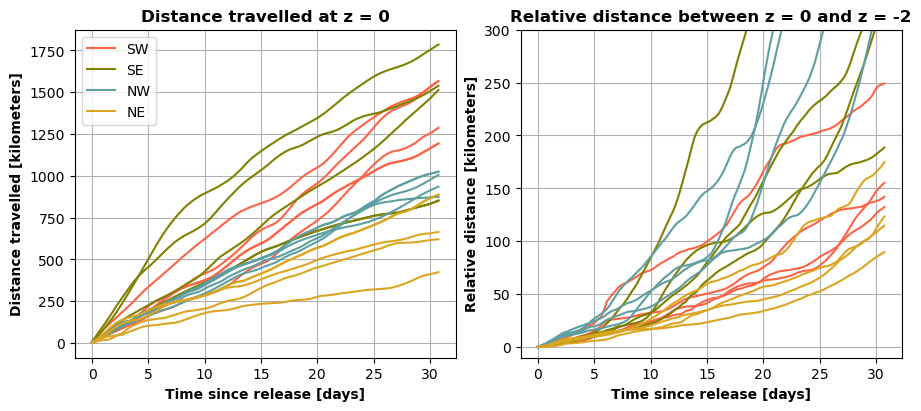

In [39]:
#Plotting distance against time that the parcels travelled
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

ax1.set_ylabel("Distance travelled [kilometers]", weight = 'bold')
ax1.set_xlabel("Time since release [days]", weight="bold")
d_plot = ax1.plot(time_in_days[3:4,:-30].transpose(), dist_km_tot[3:4,:-30].transpose(), color='tomato', label = 'SW')
d_plot = ax1.plot(time_in_days[4:5,:-30].transpose(),dist_km_tot[4:5,:-30].transpose(), color='olive', label = 'SE')
d_plot = ax1.plot(time_in_days[8:9,:-30].transpose(),dist_km_tot[8:9,:-30].transpose(), color='cadetblue', label = 'NW')
d_plot = ax1.plot(time_in_days[12:13,:-30].transpose(),dist_km_tot[12:13,:-30].transpose(), color='goldenrod', label = 'NE')
d_plot = ax1.plot(time_in_days[:4,:-30].transpose(), dist_km_tot[:4,:-30].transpose(), color='tomato')
d_plot = ax1.plot(time_in_days[4:8,:-30].transpose(),dist_km_tot[4:8,:-30].transpose(), color='olive')
d_plot = ax1.plot(time_in_days[8:12,:-30].transpose(),dist_km_tot[8:12,:-30].transpose(), color='cadetblue')
d_plot = ax1.plot(time_in_days[12:,:-30].transpose(),dist_km_tot[12:,:-30].transpose(), color='goldenrod')
ax1.set_title('Distance travelled at z = 0', weight = 'bold')
ax1.legend()
ax1.grid()

ax2.set_ylabel("Relative distance [kilometers]", weight = 'bold')
ax2.set_xlabel("Time since release [days]", weight="bold")

d_plot_t = ax2.plot(time_in_days[:4,:-30].transpose(), dist_km_ref_av_stokes[:4,:-30].transpose(), color='tomato')
d_plot_t = ax2.plot(time_in_days[4:8,:-30].transpose(),dist_km_ref_av_stokes[4:8,:-30].transpose(), color='olive')
d_plot_t = ax2.plot(time_in_days[8:12,:-30].transpose(),dist_km_ref_av_stokes[8:12,:-30].transpose(), color='cadetblue')
d_plot_t = ax2.plot(time_in_days[12:,:-30].transpose(),dist_km_ref_av_stokes[12:,:-30].transpose(), color='goldenrod')
ax2.set_ylim(-10,300)
ax2.grid()
ax2.set_title('Relative distance between z = 0 and z = -2', weight = 'bold')
plt.show()

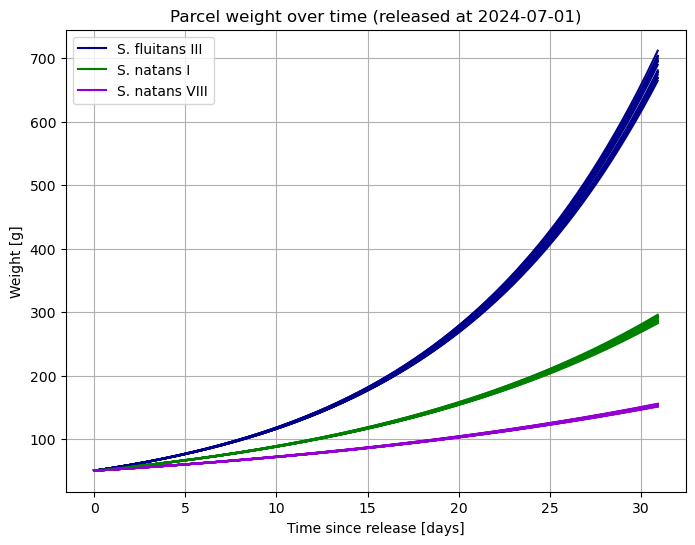

In [103]:
figweight = plt.figure(figsize = (8,6), dpi=100)
plt.plot(time_in_days.transpose(), DS.weight_SF3.transpose() , c = 'darkblue')
#plt.plot(time_in_hours.transpose(), DSJ.weight_SF3.transpose() , c = 'lightblue')
plt.plot(time_in_days.transpose(), DS.weight_SN1.transpose() , c = 'green')
#plt.plot(time_in_hours.transpose(), DSJ.weight_SN1.transpose() , c = 'lightgreen')
plt.plot(time_in_days.transpose(), DS.weight_SN8.transpose() , c = 'darkviolet')
#plt.plot(time_in_hours.transpose(), DSJ.weight_SN8.transpose() , c = 'pink')

plt.plot(time_in_days[0,:].transpose(), DS.weight_SF3[0,:].transpose() , c = 'darkblue', label = 'S. fluitans III')
plt.plot(time_in_days[0,:].transpose(), DS.weight_SN1[0,:].transpose() , c = 'green', label = 'S. natans I')
plt.plot(time_in_days[0,:].transpose(), DS.weight_SN8[0,:].transpose() , c = 'darkviolet', label = 'S. natans VIII')
plt.title(f'Parcel weight over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [days]')
plt.ylabel('Weight [g]')
#plt.yticks([50,70,90,110,130,150,170,190])
#plt.yticks([50,100,150])
#plt.ylim(45,300)
plt.legend()
plt.grid()
plt.show()

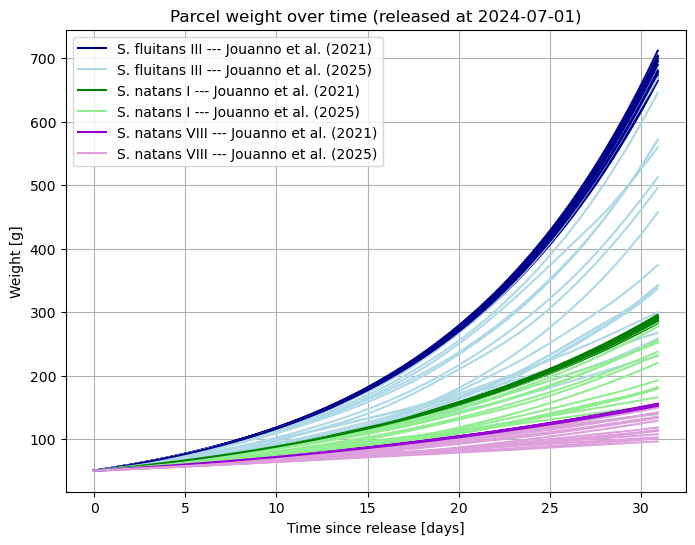

In [104]:
#Plot of weight of particles over time, comparing two different temperature kernels

figweight = plt.figure(figsize = (8,6), dpi=100)
plt.plot(time_in_days.transpose(), DS.weight_SF3.transpose() ,c = 'darkblue')
plt.plot(time_in_days.transpose(), DSJ.weight_SF3.transpose() , c = 'lightblue')
plt.plot(time_in_days.transpose(), DS.weight_SN1.transpose() , c = 'green')
plt.plot(time_in_days.transpose(), DSJ.weight_SN1.transpose() , c = 'lightgreen')
plt.plot(time_in_days.transpose(), DS.weight_SN8.transpose() , c = 'darkviolet')
plt.plot(time_in_days.transpose(), DSJ.weight_SN8.transpose() , c = 'plum')

plt.plot(time_in_days[0,:].transpose(), DS.weight_SF3[0,:].transpose() , c = 'darkblue', label = 'S. fluitans III --- Jouanno et al. (2021)')
plt.plot(time_in_days[0,:].transpose(), DSJ.weight_SF3[0,:].transpose() , c = 'lightblue', label = 'S. fluitans III --- Jouanno et al. (2025)')
plt.plot(time_in_days[0,:].transpose(), DS.weight_SN1[0,:].transpose() , c = 'green', label = 'S. natans I --- Jouanno et al. (2021)')
plt.plot(time_in_days[0,:].transpose(), DSJ.weight_SN1[0,:].transpose() , c = 'lightgreen', label = 'S. natans I --- Jouanno et al. (2025)')
plt.plot(time_in_days[0,:].transpose(), DS.weight_SN8[0,:].transpose() , c = 'darkviolet', label = 'S. natans VIII --- Jouanno et al. (2021)')
plt.plot(time_in_days[0,:].transpose(), DSJ.weight_SN8[0,:].transpose() , c = 'plum', label = 'S. natans VIII --- Jouanno et al. (2025)')
plt.title(f'Parcel weight over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [days]')
plt.ylabel('Weight [g]')
#plt.yticks([50,70,90,110,130,150,170,190])
#plt.yticks([50,100,150])
#plt.ylim(45,300)
plt.legend()
plt.grid()
plt.show()

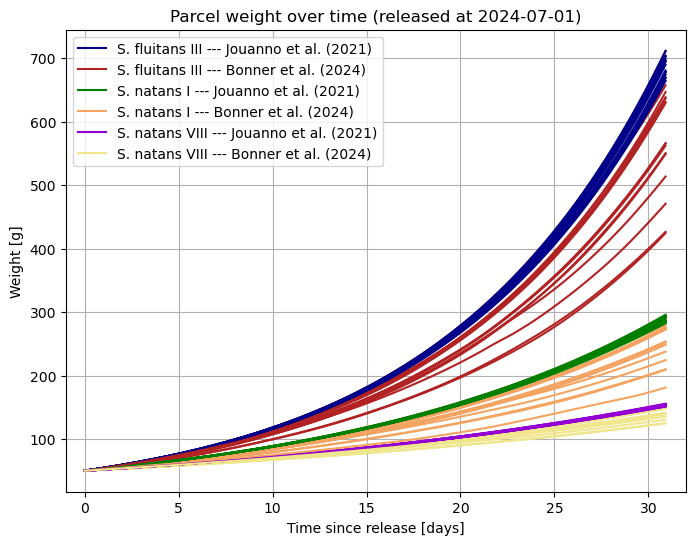

In [105]:
#Plot of weight of particles over time, comparing two simple growth kernel and Bonner growth kernel

figweight = plt.figure(figsize = (8,6), dpi=100)

plt.plot(time_in_days.transpose(), DSB.weight_SF3.transpose() , c = 'firebrick')
plt.plot(time_in_days.transpose(), DS.weight_SF3.transpose() ,c = 'darkblue')
plt.plot(time_in_days.transpose(), DSB.weight_SN1.transpose() , c = 'sandybrown')
plt.plot(time_in_days.transpose(), DS.weight_SN1.transpose() , c = 'green')
plt.plot(time_in_days.transpose(), DSB.weight_SN8.transpose() , c = 'khaki')
plt.plot(time_in_days.transpose(), DS.weight_SN8.transpose() , c = 'darkviolet')


plt.plot(time_in_days[0,:].transpose(), DS.weight_SF3[0,:].transpose() , c = 'darkblue', label = 'S. fluitans III --- Jouanno et al. (2021)')
plt.plot(time_in_days[0,:].transpose(), DSB.weight_SF3[0,:].transpose() , c = 'firebrick', label = 'S. fluitans III --- Bonner et al. (2024)')
plt.plot(time_in_days[0,:].transpose(), DS.weight_SN1[0,:].transpose() , c = 'green', label = 'S. natans I --- Jouanno et al. (2021)')
plt.plot(time_in_days[0,:].transpose(), DSJ.weight_SN1[0,:].transpose() , c = 'sandybrown', label = 'S. natans I --- Bonner et al. (2024)')
plt.plot(time_in_days[0,:].transpose(), DS.weight_SN8[0,:].transpose() , c = 'darkviolet', label = 'S. natans VIII --- Jouanno et al. (2021)')
plt.plot(time_in_days[0,:].transpose(), DSB.weight_SN8[0,:].transpose() , c = 'khaki', label = 'S. natans VIII --- Bonner et al. (2024)')
plt.title(f'Parcel weight over time (released at {starttimejuly.date()})')
plt.xlabel('Time since release [days]')
plt.ylabel('Weight [g]')
#plt.yticks([50,70,90,110,130,150,170,190])
#plt.yticks([50,100,150])
plt.xlim(-1,32)
plt.legend()
plt.grid()
plt.show()

In [63]:
#SLICING TO REMOVE NAN VALUES AT THE END OF THE ARRAYS
DS_sliced = DS.isel(obs=slice(0, 372))
DSJ_sliced = DSJ.isel(obs=slice(0,372))
DSB_sliced = DSB.isel(obs=slice(0,372))

print(DS_sliced.weight_SF3.values[0,350:])
print(DSJ_sliced.weight_SF3.values[0,350:])
print(DSB_sliced.weight_SF3.values[0,350:])

[584.822   588.947   593.10223 597.2885  601.50726 605.75696 610.04034
 614.35565 618.707   623.0911  627.5098  631.9604  636.44257 640.9551
 645.49805 650.0727  654.67914 659.31805 663.9902  668.6951  673.4345
 678.2076 ]
[302.70255 304.28445 305.88745 307.51843 309.19092 310.88602 312.63278
 314.407   316.25485 318.13757 320.0715  322.02316 323.98755 325.94666
 327.90112 329.8609  331.82562 333.79907 335.78827 337.78632 339.80872
 341.84415]
[493.80252 496.9979  500.21164 503.44705 506.70834 509.99484 513.3138
 516.65985 520.0409  523.4493  526.88837 530.3514  533.83673 537.3405
 540.8625  544.40485 547.96844 551.55597 555.1701  558.8093  562.4765
 566.16833]


In [65]:
max_SF3 = np.nanmax(DS_sliced.weight_SF3)
min_SF3 = np.nanmin(DS_sliced.weight_SF3)

div_SF3 = np.linspace(min_SF3, max_SF3, 10)
div     = np.linspace(0, 800, 9)

#Categorizing based on weight and multiplying by 100 to make each category an honderdtal
categorized = np.digitize(DS_sliced.weight_SF3, div, right=False) * 100
categorized_J = np.digitize(DSJ_sliced.weight_SF3, div, right=False) * 100
categorized_B = np.digitize(DSB_sliced.weight_SF3, div, right=False) * 100

#Storing it in dataset
DS_sliced["weight_SF3_categorized"] = (DS_sliced.weight_SF3.dims, categorized)
DSJ_sliced["weight_SF3_categorized"] = (DSJ_sliced.weight_SF3.dims, categorized_J)
DSB_sliced["weight_SF3_categorized"] = (DSB_sliced.weight_SF3.dims, categorized_B)

print(div_SF3, div, categorized, categorized_J, categorized_B)

[ 50.029087 123.58362  197.13815  270.6927   344.24722  417.80176
 491.3563   564.9108   638.4654   712.01996 ] [  0. 100. 200. 300. 400. 500. 600. 700. 800.] [[100 100 100 ... 700 700 700]
 [100 100 100 ... 700 700 700]
 [100 100 100 ... 700 700 700]
 ...
 [100 100 100 ... 700 700 800]
 [100 100 100 ... 700 700 700]
 [100 100 100 ... 700 700 700]] [[100 100 100 ... 400 400 400]
 [100 100 100 ... 400 400 400]
 [100 100 100 ... 400 400 400]
 ...
 [100 100 100 ... 700 700 700]
 [100 100 100 ... 600 600 600]
 [100 100 100 ... 500 500 500]] [[100 100 100 ... 600 600 600]
 [100 100 100 ... 600 600 600]
 [100 100 100 ... 600 600 600]
 ...
 [100 100 100 ... 700 700 700]
 [100 100 100 ... 700 700 700]
 [100 100 100 ... 700 700 700]]


In [66]:
unique_categories = np.unique(categorized)

print(len(unique_categories))
print(len(div))

8
9


unique_categories: [100 200 300 400 500 600 700 800]
number of bins: 8
boundaries: [  0 100 200 300 400 500 600 700 800]
norm: <matplotlib.colors.BoundaryNorm object at 0x7f5d748fd710>


/tmp/ipykernel_2084609/851766303.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins, )


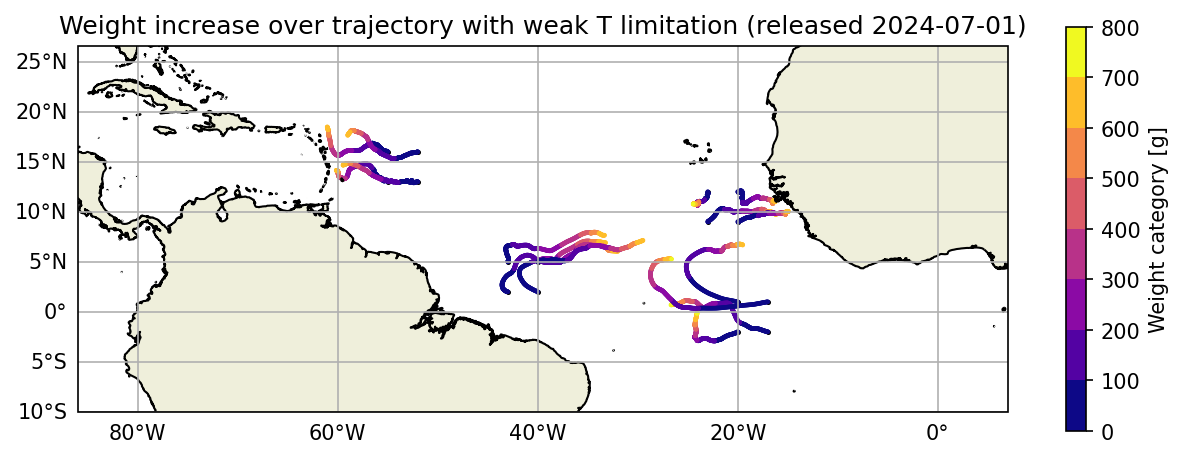

In [107]:
import matplotlib.colors as mcolors

fig2 = plt.figure(figsize = (10,7), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DS_sliced.lon[:,0], DS_sliced.lat[:,0], s = 2 ,color='black') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
print('unique_categories:', unique_categories)
number_of_bins = len(unique_categories) 
print('number of bins:', number_of_bins)
colormap = plt.cm.get_cmap('plasma', number_of_bins, )
boundaries = np.append(unique_categories - 100, unique_categories[-1] )
print('boundaries:', boundaries) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
print('norm:', norm)

# Colored scatter plot
cscat = ax.scatter(
    DS_sliced.lon, DS_sliced.lat, c = DS_sliced.weight_SF3_categorized.values - 1,
    cmap=colormap,
    norm=norm,
    s=5,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Weight increase over trajectory with weak T limitation (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_2084609/2356770285.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins, )


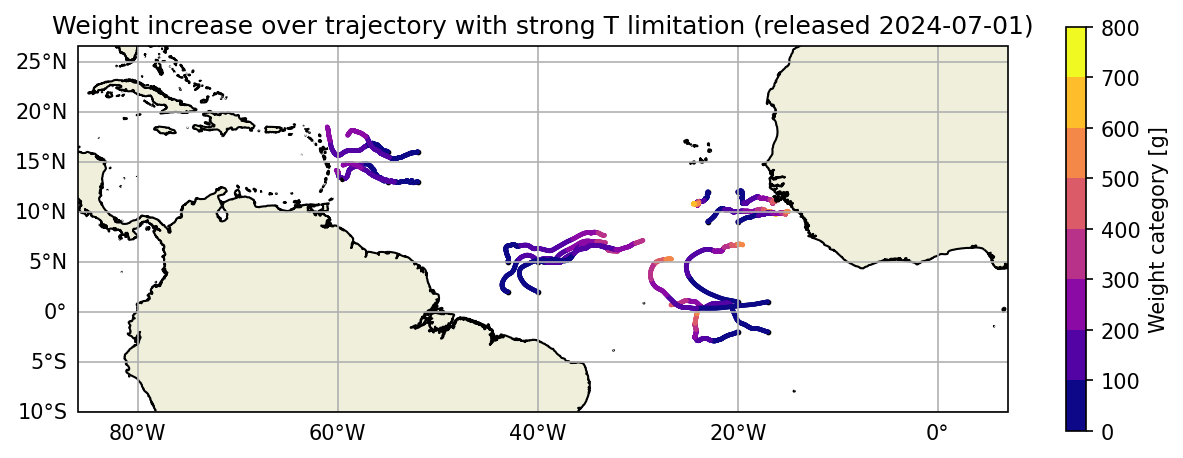

In [108]:
import matplotlib.colors as mcolors

fig2 = plt.figure(figsize = (10,7), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DSJ_sliced.lon[:,0], DSJ_sliced.lat[:,0], s = 3 ,color='black') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins, )
boundaries = np.append(unique_categories - 100, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

# Colored scatter plot
cscat = ax.scatter(
    DS_sliced.lon, DS_sliced.lat, c = DSJ_sliced.weight_SF3_categorized.values - 1,
    cmap=colormap,
    norm=norm,
    s=5,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

ax.set_title(f'Weight increase over trajectory with strong T limitation (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

/tmp/ipykernel_2084609/1058695701.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('plasma', number_of_bins, )


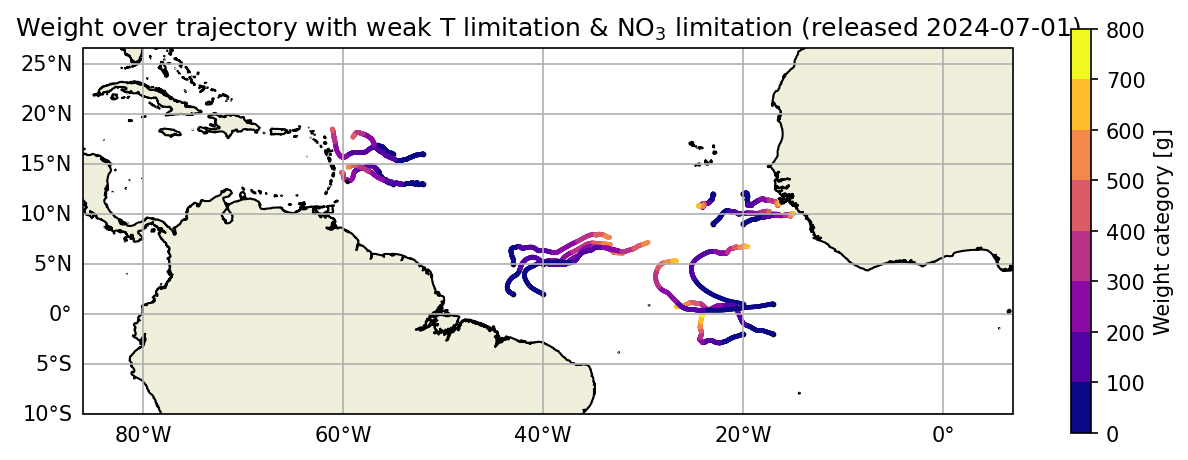

In [109]:
import matplotlib.colors as mcolors

fig3 = plt.figure(figsize = (10,7), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#Startlocations scatterplot
#pplot = ax.scatter(DS_sliced.lon[:,:], DS_sliced.lat[:,:], s = 2 ,color='black') #Transposing lon and lat arrays!
pplot = ax.scatter(DSB_sliced.lon[:,0], DSB_sliced.lat[:,0], s = 3 ,color='black') #Transposing lon and lat arrays!

unique_categories = np.unique(categorized)
number_of_bins = len(unique_categories)
colormap = plt.cm.get_cmap('plasma', number_of_bins, )
boundaries = np.append(unique_categories - 100, unique_categories[-1] ) 
norm = mcolors.BoundaryNorm(boundaries, number_of_bins)
#norm = mcolors.BoundaryNorm(np.append(unique_categories.min() - 50, , unique_categories.max()+1), number_of_bins)

# Colored scatter plot
cscat = ax.scatter(
    DSB_sliced.lon, DSB_sliced.lat, c = DSB_sliced.weight_SF3_categorized.values - 1,
    cmap=colormap,
    norm=norm,
    s=5,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

ax.set_title(f'Weight over trajectory with weak T limitation & NO$_3$ limitation (released {starttimejuly.date()})')
ax.set_extent([-86,7,-7,19])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)
plt.show()

[ 1  2  3  4  5  6  7  8  9 10]


/tmp/ipykernel_696512/4067940245.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet', n_bins, )  # or 'Set1', 'Accent', etc.


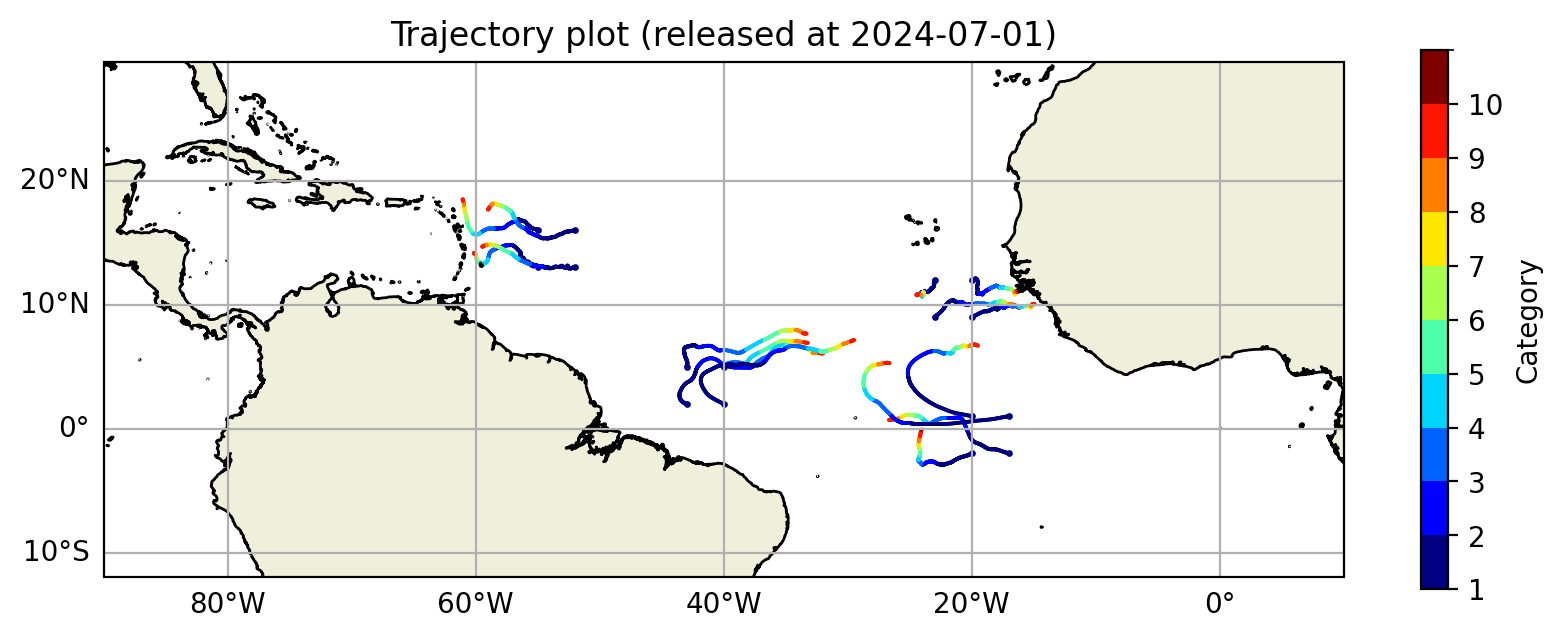

In [42]:
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import numpy as np

#Step 1: Extract the category values (same shape as lat/lon)
categories = DS.weight_SF3_category.values  # shape: (particles, time)

#Step 2: Flatten the arrays for scatter plotting
lon_flat = DS.lon.values.flatten()
lat_flat = DS.lat.values.flatten()
cat_flat = categories.flatten()

#Step 3: Remove NaNs so they don't mess up plotting
valid_mask = ~np.isnan(cat_flat)
lon_plot = lon_flat[valid_mask]
lat_plot = lat_flat[valid_mask]
cat_plot = cat_flat[valid_mask].astype(int)

#Step 4: Define discrete colormap
unique_cats = np.unique(cat_plot)
print(unique_cats)
n_bins = len(unique_cats)
cmap = plt.cm.get_cmap('jet', n_bins, )  # or 'Set1', 'Accent', etc.
norm = mcolors.BoundaryNorm(np.arange(unique_cats.min(), unique_cats.max()+2), cmap.N)

#Step 5: Plot
fig2 = plt.figure(figsize=(10, 7), dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree())

pplot = ax.scatter(DS.lon[:,0], DS.lat[:,0], s = 2 ,color='darkblue') #Transposing lon and lat arrays!
# Colored scatter plot
sc = ax.scatter(
    lon_plot,
    lat_plot,
    c=cat_plot,
    cmap=cmap,
    norm=norm,
    s=2,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

# Map features
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
ax.add_feature(cfeature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left', 'bottom'], zorder=0)
ax.set_title(f'Trajectory plot (released at {starttimejuly.date()})')
ax.set_extent([-90, 10, -8, 20])

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', label='Category', shrink=0.5)
cbar.set_ticks(unique_cats)
#cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
# Optional: cbar.set_ticklabels([...]) for named categories

plt.show()

In [7]:

from math import sin, cos, sqrt, atan2, radians, pi

def dist_km(lona, lonb, lata, latb):
    """
    Function to calculate the distance between 2 points in km
    Haversine formula used, which assumes the Earth is a sphere.
    source: https://stackoverflow.com/questions/19412462/getting-distance-between-two-points-based-on-latitude-longitude
    """
    
    R = 6371.0     # approximate radius of earth in km

    lat1 = radians(lata)
    lon1 = radians(lona)
    lat2 = radians(latb)
    lon2 = radians(lonb)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c

    return distance

def cumulative_distance_01(ds_n, nsavedir=None):
    
    # Creating the output data array:
    dist_01 = ds_n.lon.copy() * np.nan

    # Calculating the distance traveled by every particle at every timestep:
    for tt in range(0, len(ds_n.trajectory)):           #Changed ds_n.traj to ds_n.trajectory 
        lon_t = ds_n.lon[tt, :].dropna(dim='obs')
        lat_t = ds_n.lat[tt, :].dropna(dim='obs')
        
        for oo in range(1, len(lat_t)): # calculate as distance at x0 = distance at x-x0
            dist_01[tt, oo-1] = dist_km(lon_t[oo-1], lon_t[oo], lat_t[oo-1], lat_t[oo])
    
    # Calculating the cumulative distance traveled for all particle trajectories at every timestep:
    cum_dist_01 = dist_01.cumsum(dim='obs')
    
    if nsavedir:
        cum_dist_01.to_netcdf(nsavedir + "cum_dist_01.nc")
    
    return cum_dist_01

cumulative_distances_km = cumulative_distance_01(DS)